# Clasificación de aves con SqueezeNet

### Carga de librerías

In [1]:
import os
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.models import SqueezeNet1_1_Weights

import ssl
import certifi

ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())

In [2]:
N_CPU = os.cpu_count() or 4
N_INTEROP = max(1, N_CPU // 2)

print(f"N_CPU: {N_CPU}, N_INTEROP: {N_INTEROP}")

torch.set_num_threads(N_CPU)
torch.set_num_interop_threads(N_INTEROP) 

N_CPU: 12, N_INTEROP: 6


## Configuración

### Configuración del modelo

In [3]:
weights = SqueezeNet1_1_Weights.IMAGENET1K_V1
preprocess = weights.transforms()

# Se obtienen el tamaño de las imagenes utilizadas en SqueezeNet
preprocess_crop_size = preprocess.crop_size
preprocess_resize_size = preprocess.resize_size

print(f"Tamaño de recorte (Crop): {preprocess_crop_size}")
print(f"Tamaño de reescalado (Resize): {preprocess_resize_size}")

# Se obtienen los pesos de normalización de las imagenes utilizadas en SqueezeNet
preprocess_mean = preprocess.mean
preprocess_std = preprocess.std

print(f"Media de normalización: {preprocess_mean}")
print(f"Desviación estándar de normalización: {preprocess_std}")

Tamaño de recorte (Crop): [224]
Tamaño de reescalado (Resize): [256]
Media de normalización: [0.485, 0.456, 0.406]
Desviación estándar de normalización: [0.229, 0.224, 0.225]


In [4]:
class Config:
    
    # Dataset
    dataset_root = "Dataset_Imagenes_Robustas"

    train_dir = os.path.join(dataset_root, "Training")
    val_dir = os.path.join(dataset_root, "Validation")
    test_dir = os.path.join(dataset_root, "Testing")

    # Preprocesamiento
    preprocess_crop_size = 224
    preprocess_resize_size = 256

    preprocess_mean = [0.485, 0.456, 0.406]
    preprocess_std = [0.229, 0.224, 0.225]

    image_size = preprocess_crop_size

    batch_size = 64
    lr = 1e-4
    epochs = 50

    # Se determina el dispositivo de cómputo (GPU, MPS o CPU)
    if os.name == 'nt':
        device = "cuda" if torch.cuda.is_available() else "cpu"
    else:
        device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

    num_workers = 8
    
    
    print(device)
    
    # Modelo
    freeze_features = True
    num_classes = 21

    model_path = "best_squeezenet_birds_images_v2.pth"

mps


In [5]:
cfg = Config()

## Dataset

In [6]:
def get_dataloaders(cfg: Config):
    """
    cfg: parámetros generales de configuración

    Realiza:
        - Transformaciones de entrenamiento y evaluación
        - Generación de los datasets
        - Generación de los DataLoaders

    Retorna:
        - train_dataset: Dataset de entrenamiento
        - val_dataset: Dataset de validación
        - test_dataset: Dataset de test (puede ser None si no existe)
        - train_loader: DataLoader de entrenamiento
        - val_loader: DataLoader de validación
        - test_loader: DataLoader de test (puede ser None si no existe)
    """
    use_pin_memory = str(cfg.device) == "cuda" # Evitar warning


    # Transformaciones para entrenamiento y evaluación
    train_transform = transforms.Compose([
        transforms.Resize((cfg.image_size, cfg.image_size)),
        # transforms.RandomRotation(degrees=5),
        transforms.ToTensor(), # [batch_size, channels, height, width]
        transforms.Normalize(mean=cfg.preprocess_mean, std=cfg.preprocess_std),
    ])

    eval_transform = transforms.Compose([
        transforms.Resize((cfg.image_size, cfg.image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=cfg.preprocess_mean, std=cfg.preprocess_std),
    ])

    # Datasets
    train_dataset = datasets.ImageFolder(cfg.train_dir, transform=train_transform)
    val_dataset = datasets.ImageFolder(cfg.val_dir, transform=eval_transform)

    test_dataset = None
    if Path(cfg.test_dir).exists():
        test_dataset = datasets.ImageFolder(cfg.test_dir, transform=eval_transform)

    train_loader = DataLoader(
        train_dataset,
        batch_size=cfg.batch_size,
        shuffle=True,
        num_workers=cfg.num_workers,
        pin_memory=use_pin_memory
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=cfg.batch_size,
        shuffle=False,
        num_workers=cfg.num_workers,
        pin_memory=use_pin_memory
    )

    test_loader = None
    if test_dataset is not None:
        test_loader = DataLoader(
            test_dataset,
            batch_size=cfg.batch_size,
            shuffle=False,
            num_workers=cfg.num_workers,
            pin_memory=use_pin_memory
        )

    return train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader


## SqueezeNet

In [7]:
weights = SqueezeNet1_1_Weights.DEFAULT
model_squeezenet = models.squeezenet1_1(weights=weights)
print(model_squeezenet)

SqueezeNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
    (3): Fire(
      (squeeze): Conv2d(64, 16, kernel_size=(1, 1), stride=(1, 1))
      (squeeze_activation): ReLU(inplace=True)
      (expand1x1): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
      (expand1x1_activation): ReLU(inplace=True)
      (expand3x3): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (expand3x3_activation): ReLU(inplace=True)
    )
    (4): Fire(
      (squeeze): Conv2d(128, 16, kernel_size=(1, 1), stride=(1, 1))
      (squeeze_activation): ReLU(inplace=True)
      (expand1x1): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
      (expand1x1_activation): ReLU(inplace=True)
      (expand3x3): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (expand3x3_activation): ReLU(inplace=True)
    )
    (5): MaxPool2d

## Preparación para el entrenamiento

### Configuración del entrenamiento

In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    # Inicializar variables de entrenamiento
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    
    # Iteración sobre los batches del DataLoader
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    loss_epoch = total_loss / total_samples
    acc_epoch = total_correct / total_samples
    return loss_epoch, acc_epoch


### Configuración de evaluación

In [9]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    # Inicializar variables de evaluación
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

    loss_epoch = total_loss / total_samples
    acc_epoch = total_correct / total_samples
    return loss_epoch, acc_epoch, all_labels, all_preds

## Entrenamiento

### Entrenamiento con aumento progresivo de capas entrenables

1. Se genera un cronograma de descongelamiento en dos etapas. El objetivo es la busqueda optima de descongelamiento, desde el entrenamiento unico de la capa de clasificación hasta el entrenamiento de todas las capas del modelo SqueezeNet.
    - Etapa 1: descongelar de a 4 capas.
    - Etapas 2: ajuste fino, descongelando de a 1 una capa alrededor de la mejor configuración de la etapa 1.
2. Para cada experimento, un nuevo modelo.
3. Se entrenan 20 epocas por modelo, sin early stopping.
4. Cada 5 epocas se guarda el classification report.
5. Guarda metricas de desempeño por época: perdida y exactitud de entrenamiento y validación.
6. Se guarda el mejor modelo de cada experimento.


In [11]:
import os
from pathlib import Path
from copy import deepcopy

import torch
import torch.nn as nn
import torchvision.models as models
from torchvision.models import SqueezeNet1_1_Weights
from sklearn.metrics import classification_report

In [12]:
def build_squeezenet(num_classes: int):
    weights = SqueezeNet1_1_Weights.DEFAULT
    model = models.squeezenet1_1(weights=weights)
    model.classifier[1] = nn.Conv2d(512, num_classes, kernel_size=1)
    model.num_classes = num_classes
    return model

In [13]:
def set_trainable_layers_squeezenet(model, mode):
    """
    mode puede ser:
    - 0   -> solo classifier
    - 4   -> últimas 4 capas de features
    - 8   -> últimas 8 capas de features
    - "all" -> todo features
    """
    total_feature_layers = len(model.features)

    # congelar todo features
    for param in model.features.parameters():
        param.requires_grad = False

    # classifier siempre entrenable
    for param in model.classifier.parameters():
        param.requires_grad = True

    if mode == "all":
        for param in model.features.parameters():
            param.requires_grad = True
        n_unfrozen = total_feature_layers

    elif isinstance(mode, int) and mode > 0:
        start_idx = max(0, total_feature_layers - mode)
        for idx in range(start_idx, total_feature_layers):
            for param in model.features[idx].parameters():
                param.requires_grad = True
        n_unfrozen = mode

    else:
        n_unfrozen = 0

    return model, n_unfrozen, total_feature_layers

In [14]:
def build_optimizer(model, lr_features=1e-5, lr_classifier=1e-4, momentum=0.9, weight_decay=1e-4):
    feature_params = [p for p in model.features.parameters() if p.requires_grad]
    classifier_params = [p for p in model.classifier.parameters() if p.requires_grad]

    param_groups = []
    if len(feature_params) > 0:
        param_groups.append({"params": feature_params, "lr": lr_features})
    if len(classifier_params) > 0:
        param_groups.append({"params": classifier_params, "lr": lr_classifier})

    optimizer = torch.optim.SGD(
        param_groups,
        momentum=momentum,
        weight_decay=weight_decay
    )
    return optimizer

In [15]:
def get_unfreeze_schedule(total_feature_layers: int, step: int = 2):
    """
    Genera la secuencia:
    0, 2, 4, 6, ... hasta total_feature_layers
    """
    schedule = list(range(0, total_feature_layers + 1, step))
    if schedule[-1] != total_feature_layers:
        schedule.append(total_feature_layers)
    return schedule


def make_experiment_name(n_unfrozen: int, total_feature_layers: int):
    if n_unfrozen == 0:
        return "exp_classifier_only"
    elif n_unfrozen >= total_feature_layers:
        return f"exp_unfreeze_all_{total_feature_layers}_feature_layers"
    else:
        return f"exp_unfreeze_last_{n_unfrozen}_feature_layers"

In [16]:
def get_trainable_params_count(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

def mode_to_name(mode):
    if mode == 0:
        return "classifier_only"
    if mode == "all":
        return "unfreeze_all"
    return f"unfreeze_last_{mode}"

In [17]:
def run_single_experiment(
    cfg,
    train_dataset,
    train_loader,
    val_loader,
    criterion,
    mode,
    epochs,
    save_dir,
    report_every=None,
    lr_features=1e-5,
    lr_classifier=1e-4,
):
    os.makedirs(save_dir, exist_ok=True)

    num_classes = len(train_dataset.classes)

    model = build_squeezenet(num_classes)
    model, n_unfrozen, total_feature_layers = set_trainable_layers_squeezenet(model, mode)
    model = model.to(cfg.device)

    optimizer = build_optimizer(
        model,
        lr_features=lr_features,
        lr_classifier=lr_classifier
    )

    total_params, trainable_params = get_trainable_params_count(model)

    print("\n" + "=" * 80)
    print(f"Experimento: {mode_to_name(mode)}")
    print(f"Feature layers descongeladas: {n_unfrozen}/{total_feature_layers}")
    print(f"Total params: {total_params:,}")
    print(f"Trainable params: {trainable_params:,}")
    print("=" * 80)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    classification_reports = {}

    best_val_acc = -1.0
    best_epoch = -1
    best_state_dict = None

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, cfg.device
        )

        val_loss, val_acc, y_true, y_pred = evaluate(
            model, val_loader, criterion, cfg.device
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(
            f"[{mode_to_name(mode)}] Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )

        save_report_now = False
        if report_every is not None and (epoch + 1) % report_every == 0:
            save_report_now = True
        if epoch + 1 == epochs:
            save_report_now = True

        if save_report_now:
            report_str = classification_report(
                y_true,
                y_pred,
                target_names=train_dataset.classes,
                zero_division=0
            )

            classification_reports[f"epoch_{epoch+1}"] = report_str

            report_path = os.path.join(
                save_dir,
                f"classification_report_epoch_{epoch+1}.txt"
            )
            with open(report_path, "w", encoding="utf-8") as f:
                f.write(report_str)

            print("\nClassification Report:")
            print(report_str)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            best_state_dict = deepcopy(model.state_dict())

    summary = {
        "mode": mode,
        "experiment_name": mode_to_name(mode),
        "n_unfrozen_feature_layers": n_unfrozen,
        "total_feature_layers": total_feature_layers,
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
        "classes": train_dataset.classes,
        "class_to_idx": train_dataset.class_to_idx,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs,
        "classification_reports": classification_reports,
        "best_model_state_dict": best_state_dict,
        "total_params": total_params,
        "trainable_params": trainable_params,
    }

    torch.save(summary, os.path.join(save_dir, f"{mode_to_name(mode)}_summary.pth"))

    return summary

In [18]:
def run_phase_1_screening(
    cfg,
    train_dataset,
    train_loader,
    val_loader,
    criterion,
    save_root="experiments_squeezenet",
    phase1_epochs=8,
):
    phase1_dir = os.path.join(save_root, "phase_1_screening")
    os.makedirs(phase1_dir, exist_ok=True)

    candidate_modes = [0, 4, 8, "all"]

    phase1_results = []

    for mode in candidate_modes:
        exp_dir = os.path.join(phase1_dir, mode_to_name(mode))

        result = run_single_experiment(
            cfg=cfg,
            train_dataset=train_dataset,
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion,
            mode=mode,
            epochs=phase1_epochs,
            save_dir=exp_dir,
            report_every=None,   # solo al final de fase 1
            lr_features=1e-5,
            lr_classifier=1e-4,
        )

        phase1_results.append({
            "mode": result["mode"],
            "experiment_name": result["experiment_name"],
            "best_val_acc": result["best_val_acc"],
            "best_epoch": result["best_epoch"],
            "summary_path": os.path.join(exp_dir, f"{mode_to_name(mode)}_summary.pth"),
        })

    phase1_results = sorted(phase1_results, key=lambda x: x["best_val_acc"], reverse=True)

    torch.save(phase1_results, os.path.join(phase1_dir, "phase_1_results_ranked.pth"))

    print("\n" + "=" * 80)
    print("RANKING FASE 1")
    print("=" * 80)
    for r in phase1_results:
        print(r)

    top2_modes = [phase1_results[0]["mode"], phase1_results[1]["mode"]]
    return phase1_results, top2_modes

In [19]:
def run_phase_2_refinement(
    cfg,
    train_dataset,
    train_loader,
    val_loader,
    criterion,
    top2_modes,
    save_root="experiments_squeezenet",
    phase2_epochs=20,
):
    phase2_dir = os.path.join(save_root, "phase_2_refinement")
    os.makedirs(phase2_dir, exist_ok=True)

    phase2_results = []

    for mode in top2_modes:
        exp_dir = os.path.join(phase2_dir, mode_to_name(mode))

        result = run_single_experiment(
            cfg=cfg,
            train_dataset=train_dataset,
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion,
            mode=mode,
            epochs=phase2_epochs,
            save_dir=exp_dir,
            report_every=5,   # cada 5 epocas
            lr_features=1e-5,
            lr_classifier=1e-4,
        )

        phase2_results.append({
            "mode": result["mode"],
            "experiment_name": result["experiment_name"],
            "best_val_acc": result["best_val_acc"],
            "best_epoch": result["best_epoch"],
            "summary_path": os.path.join(exp_dir, f"{mode_to_name(mode)}_summary.pth"),
        })

    phase2_results = sorted(phase2_results, key=lambda x: x["best_val_acc"], reverse=True)

    torch.save(phase2_results, os.path.join(phase2_dir, "phase_2_results_ranked.pth"))

    print("\n" + "=" * 80)
    print("RANKING FASE 2")
    print("=" * 80)
    for r in phase2_results:
        print(r)

    return phase2_results

In [20]:
def run_two_phase_squeezenet_experiments(
    cfg,
    train_dataset,
    train_loader,
    val_loader,
    criterion,
    save_root="experiments_squeezenet",
    phase1_epochs=8,
    phase2_epochs=20,
):
    print("\n" + "#" * 100)
    print("FASE 1 - SCREENING RAPIDO")
    print("#" * 100)

    phase1_results, top2_modes = run_phase_1_screening(
        cfg=cfg,
        train_dataset=train_dataset,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        save_root=save_root,
        phase1_epochs=phase1_epochs,
    )

    print("\nTop 2 configuraciones seleccionadas para Fase 2:", top2_modes)

    print("\n" + "#" * 100)
    print("FASE 2 - REFINAMIENTO")
    print("#" * 100)

    phase2_results = run_phase_2_refinement(
        cfg=cfg,
        train_dataset=train_dataset,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        top2_modes=top2_modes,
        save_root=save_root,
        phase2_epochs=phase2_epochs,
    )

    final_summary = {
        "phase1_results": phase1_results,
        "top2_modes": top2_modes,
        "phase2_results": phase2_results,
    }

    torch.save(final_summary, os.path.join(save_root, "two_phase_final_summary.pth"))

    return final_summary

In [21]:
train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader = get_dataloaders(cfg)

criterion = nn.CrossEntropyLoss()

In [30]:
final_summary = run_two_phase_squeezenet_experiments(
    cfg=cfg,
    train_dataset=train_dataset,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    save_root="experiments_squeezenet",
    phase1_epochs=8,
    phase2_epochs=20,
)


####################################################################################################
FASE 1 - SCREENING RAPIDO
####################################################################################################

Experimento: classifier_only
Feature layers descongeladas: 0/13
Total params: 729,678
Trainable params: 7,182
[classifier_only] Epoch [1/8] | Train Loss: 2.1686 | Train Acc: 0.3184 | Val Loss: 2.1892 | Val Acc: 0.3190
[classifier_only] Epoch [2/8] | Train Loss: 1.7309 | Train Acc: 0.4814 | Val Loss: 1.9938 | Val Acc: 0.3800
[classifier_only] Epoch [3/8] | Train Loss: 1.5330 | Train Acc: 0.5490 | Val Loss: 1.8608 | Val Acc: 0.4211
[classifier_only] Epoch [4/8] | Train Loss: 1.3906 | Train Acc: 0.5996 | Val Loss: 1.7171 | Val Acc: 0.4647
[classifier_only] Epoch [5/8] | Train Loss: 1.2711 | Train Acc: 0.6391 | Val Loss: 1.6213 | Val Acc: 0.4894
[classifier_only] Epoch [6/8] | Train Loss: 1.1850 | Train Acc: 0.6608 | Val Loss: 1.5411 | Val Acc: 0.5126
[classifier_

## Evaluación

#### Carga de métricas

In [25]:
from pathlib import Path
import torch
import pandas as pd
import matplotlib.pyplot as plt

EXP_ROOT = Path("experiments_squeezenet")

def load_pth(path):
    return torch.load(path, map_location="cpu", weights_only=False)

summary_paths = sorted(EXP_ROOT.glob("**/*_summary.pth"))

rows = []
summaries = {}

for p in summary_paths:
    s = load_pth(p)
    # filtra solo summary de experimento (no two_phase_final_summary)
    needed = {"best_val_acc", "best_epoch", "train_losses", "val_losses", "train_accs", "val_accs"}
    if isinstance(s, dict) and needed.issubset(set(s.keys())):
        summaries[str(p)] = s
        rows.append({
            "summary_path": str(p),
            "experiment_name": s.get("experiment_name"),
            "mode": s.get("mode"),
            "best_val_acc": s.get("best_val_acc"),
            "best_epoch": s.get("best_epoch"),
            "epochs_run": len(s.get("train_losses", [])),
            "trainable_params": s.get("trainable_params"),
            "total_params": s.get("total_params"),
        })

df_metrics = pd.DataFrame(rows).sort_values("best_val_acc", ascending=False).reset_index(drop=True)
display(df_metrics)


,summary_path,experiment_name,mode,best_val_acc,best_epoch,epochs_run,trainable_params,total_params
0,experiments_squeezenet/phase_2_refinement/unfr...,unfreeze_all,all,0.843175,18,20,729678,729678
1,experiments_squeezenet/phase_2_refinement/unfr...,unfreeze_last_8,8,0.810745,20,20,704046,729678
2,experiments_squeezenet/phase_1_screening/unfre...,unfreeze_all,all,0.684414,8,8,729678,729678
3,experiments_squeezenet/phase_1_screening/unfre...,unfreeze_last_8,8,0.680542,8,8,704046,729678
4,experiments_squeezenet/phase_1_screening/unfre...,unfreeze_last_4,4,0.635528,8,8,609262,729678
5,experiments_squeezenet/phase_1_screening/class...,classifier_only,0,0.549855,8,8,7182,729678


### Evolución de los modelos por época

In [27]:
def inspect_summary(summary_path: str):
    s = summaries.get(summary_path, load_pth(summary_path))

    print(f"Experimento: {s['experiment_name']} | mode={s['mode']}")
    print(f"Best val_acc: {s['best_val_acc']:.4f} (epoch {s['best_epoch']})")

    epochs = range(1, len(s["train_losses"]) + 1)

    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(epochs, s["train_losses"], label="train_loss")
    plt.plot(epochs, s["val_losses"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss - {s['experiment_name']}")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, s["train_accs"], label="train_acc")
    plt.plot(epochs, s["val_accs"], label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy - {s['experiment_name']}")
    plt.legend()

    plt.tight_layout()
    plt.show()

    # report guardado en el dict
    key = f"epoch_{s['best_epoch']}"
    report = s.get("classification_reports", {}).get(key, None)
    if report is not None:
        print(f"\nClassification report guardado ({key}):\n")
        print(report)
    else:
        print(f"\nNo hay report guardado para {key}.")
        print("Disponibles:", list(s.get("classification_reports", {}).keys()))


In [ ]:
phase1_ranked = load_pth(EXP_ROOT / "phase_1_screening" / "phase_1_results_ranked.pth")
phase2_ranked = load_pth(EXP_ROOT / "phase_2_refinement" / "phase_2_results_ranked.pth")
two_phase = load_pth(EXP_ROOT / "two_phase_final_summary.pth")

print("Phase 1 ranked:")
display(pd.DataFrame(phase1_ranked))

print("\nPhase 2 ranked:")
display(pd.DataFrame(phase2_ranked))

print("\nTwo-phase summary keys:", two_phase.keys())


#### Etapa 1 - Búsqueda de la mejor configuración

Experimento: classifier_only | mode=0
Best val_acc: 0.5499 (epoch 8)


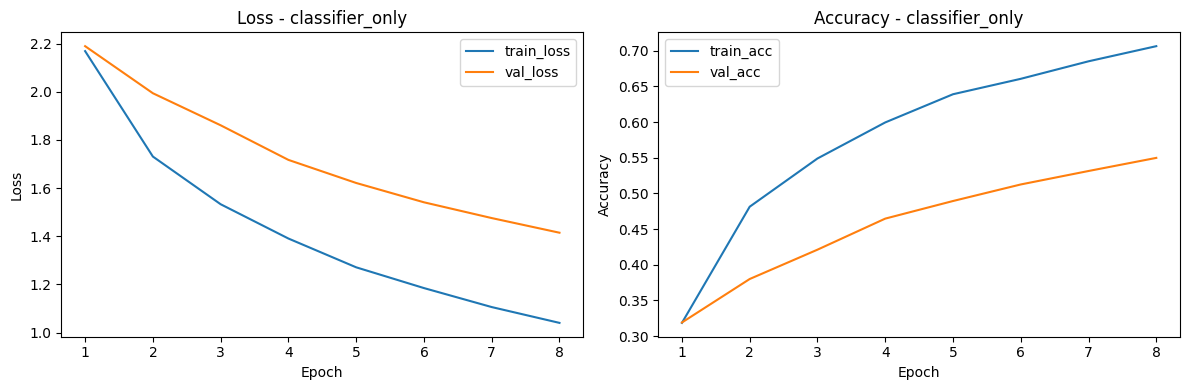


Classification report guardado (epoch_8):

                                       precision    recall  f1-score   support

         Fringillidae_Serinus_serinus       0.54      0.48      0.51       155
         Paridae_Hypocnemis_peruviana       0.00      0.00      0.00        34
             Paridae_Saxicola_rubetra       0.66      0.77      0.71       409
            Paridae_Saxicola_rubicola       0.51      0.36      0.42       213
                           Sin_Pajaro       0.00      0.00      0.00        19
      Troglodytidae_Troglodytes_aedon       0.50      0.66      0.57       252
   Troglodytidae_Troglodytes_hiemalis       0.73      0.59      0.65        70
  Troglodytidae_Troglodytes_pacificus       0.64      0.08      0.14        90
Troglodytidae_Troglodytes_troglodytes       0.54      0.77      0.64       261
    Turdidae_Catharus_aurantiirostris       0.41      0.68      0.51       154
           Turdidae_Catharus_fuscater       0.74      0.33      0.45       171
       

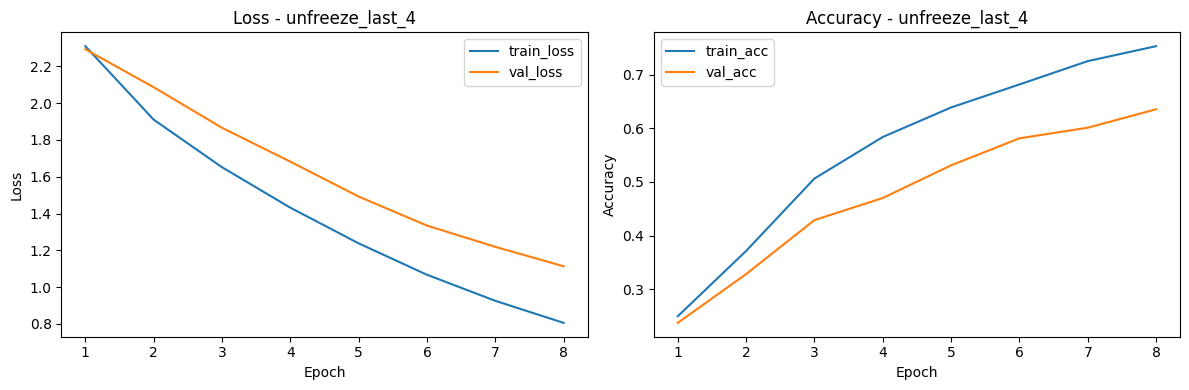


Classification report guardado (epoch_8):

                                       precision    recall  f1-score   support

         Fringillidae_Serinus_serinus       0.66      0.59      0.62       155
         Paridae_Hypocnemis_peruviana       0.33      0.38      0.36        34
             Paridae_Saxicola_rubetra       0.77      0.75      0.76       409
            Paridae_Saxicola_rubicola       0.49      0.67      0.56       213
                           Sin_Pajaro       0.75      0.32      0.44        19
      Troglodytidae_Troglodytes_aedon       0.67      0.65      0.66       252
   Troglodytidae_Troglodytes_hiemalis       0.72      0.76      0.74        70
  Troglodytidae_Troglodytes_pacificus       0.79      0.17      0.28        90
Troglodytidae_Troglodytes_troglodytes       0.63      0.79      0.70       261
    Turdidae_Catharus_aurantiirostris       0.58      0.64      0.60       154
           Turdidae_Catharus_fuscater       0.69      0.68      0.69       171
       

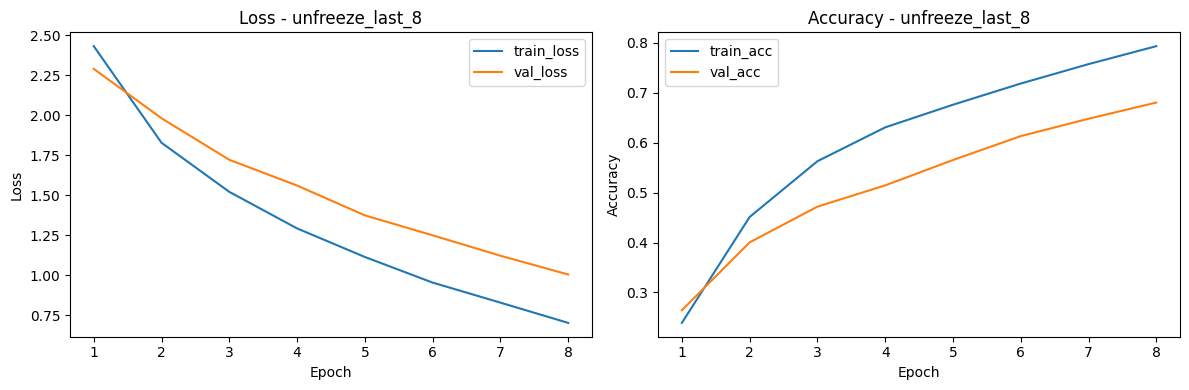


Classification report guardado (epoch_8):

                                       precision    recall  f1-score   support

         Fringillidae_Serinus_serinus       0.68      0.65      0.66       155
         Paridae_Hypocnemis_peruviana       0.53      0.24      0.33        34
             Paridae_Saxicola_rubetra       0.79      0.79      0.79       409
            Paridae_Saxicola_rubicola       0.62      0.62      0.62       213
                           Sin_Pajaro       0.00      0.00      0.00        19
      Troglodytidae_Troglodytes_aedon       0.65      0.61      0.63       252
   Troglodytidae_Troglodytes_hiemalis       0.85      0.81      0.83        70
  Troglodytidae_Troglodytes_pacificus       0.84      0.34      0.49        90
Troglodytidae_Troglodytes_troglodytes       0.66      0.87      0.75       261
    Turdidae_Catharus_aurantiirostris       0.51      0.78      0.62       154
           Turdidae_Catharus_fuscater       0.81      0.68      0.74       171
       

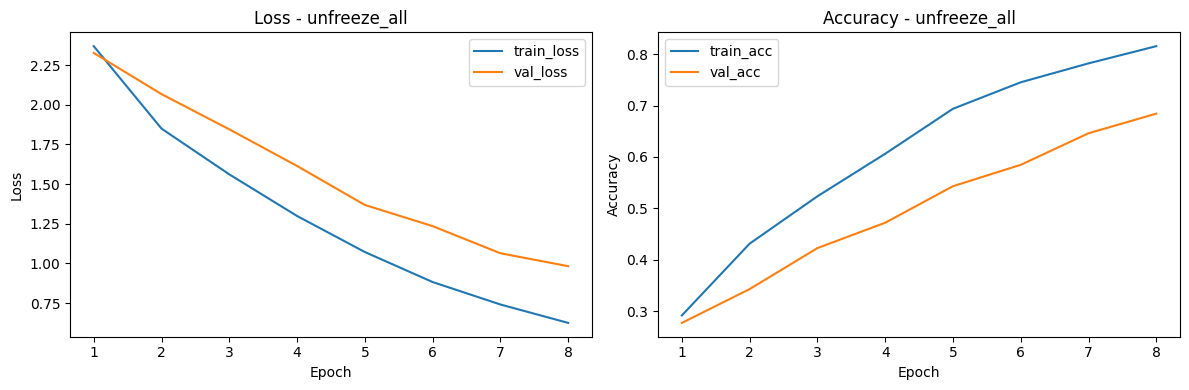


Classification report guardado (epoch_8):

                                       precision    recall  f1-score   support

         Fringillidae_Serinus_serinus       0.72      0.70      0.71       155
         Paridae_Hypocnemis_peruviana       0.88      0.44      0.59        34
             Paridae_Saxicola_rubetra       0.90      0.67      0.77       409
            Paridae_Saxicola_rubicola       0.50      0.80      0.62       213
                           Sin_Pajaro       0.00      0.00      0.00        19
      Troglodytidae_Troglodytes_aedon       0.63      0.78      0.70       252
   Troglodytidae_Troglodytes_hiemalis       0.87      0.76      0.81        70
  Troglodytidae_Troglodytes_pacificus       0.78      0.47      0.58        90
Troglodytidae_Troglodytes_troglodytes       0.74      0.80      0.77       261
    Turdidae_Catharus_aurantiirostris       0.57      0.70      0.63       154
           Turdidae_Catharus_fuscater       0.67      0.63      0.65       171
       

In [28]:
inspect_summary("experiments_squeezenet/phase_1_screening/classifier_only/classifier_only_summary.pth")
inspect_summary("experiments_squeezenet/phase_1_screening/unfreeze_last_4/unfreeze_last_4_summary.pth")
inspect_summary("experiments_squeezenet/phase_1_screening/unfreeze_last_8/unfreeze_last_8_summary.pth")
inspect_summary("experiments_squeezenet/phase_1_screening/unfreeze_all/unfreeze_all_summary.pth")

#### Etapa 2 - Desempeño de la mejor configuración

Experimento: unfreeze_all | mode=all
Best val_acc: 0.8432 (epoch 18)


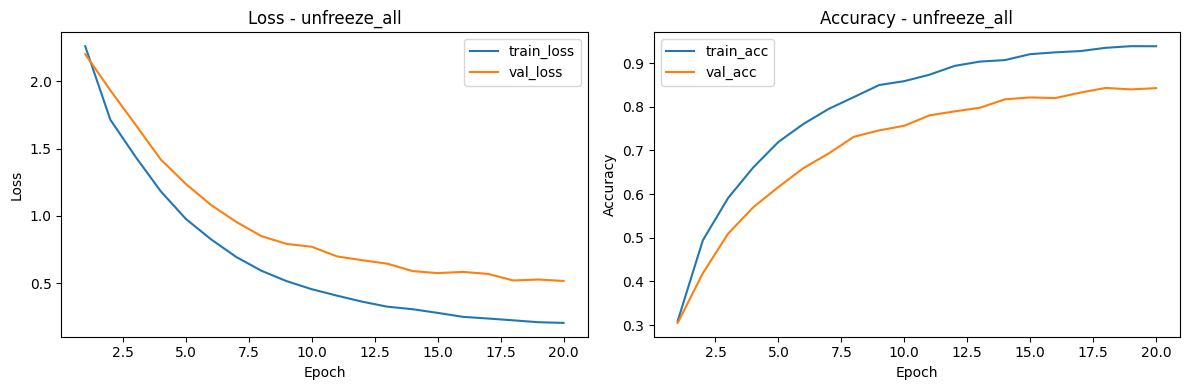


No hay report guardado para epoch_18.
Disponibles: ['epoch_5', 'epoch_10', 'epoch_15', 'epoch_20']


In [29]:
inspect_summary("experiments_squeezenet/phase_2_refinement/unfreeze_all/unfreeze_all_summary.pth")

In [32]:
s = torch.load(
    "experiments_squeezenet/phase_2_refinement/unfreeze_all/unfreeze_all_summary.pth",
    map_location="cpu",
    weights_only=False
)

print("Classification report (epoch_20) - Sin capas congeladas:")
print(s["classification_reports"]["epoch_20"])


Classification report (epoch_20) - Sin capas congeladas:
                                       precision    recall  f1-score   support

         Fringillidae_Serinus_serinus       0.85      0.89      0.87       155
         Paridae_Hypocnemis_peruviana       0.82      0.41      0.55        34
             Paridae_Saxicola_rubetra       0.90      0.88      0.89       409
            Paridae_Saxicola_rubicola       0.77      0.90      0.83       213
                           Sin_Pajaro       0.56      0.47      0.51        19
      Troglodytidae_Troglodytes_aedon       0.85      0.81      0.83       252
   Troglodytidae_Troglodytes_hiemalis       0.92      0.96      0.94        70
  Troglodytidae_Troglodytes_pacificus       0.86      0.56      0.68        90
Troglodytidae_Troglodytes_troglodytes       0.82      0.88      0.85       261
    Turdidae_Catharus_aurantiirostris       0.73      0.86      0.79       154
           Turdidae_Catharus_fuscater       0.95      0.81      0.88     